In [1]:
from datascience import *
import pandas as pd
import seaborn as sns
import numpy as np
import math

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [2]:
dat = Table.read_table("hip_cat_2.csv", sep=',')
dat.show(5)

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc),x,y,z
1,0.00091185,1.08901,9.1,3.54,1.84502,282.486,282.435,0.00449489,5.36885
2,0.00379737,-19.4988,9.27,21.9,5.97222,45.6621,43.0433,0.00285276,-15.2414
3,0.00500795,38.8593,6.61,2.81,-1.14647,355.872,277.114,0.0242212,223.278
4,0.0083817,-51.8935,8.06,7.75,2.50651,129.032,79.629,0.0116488,-101.531
5,0.00996534,-40.5912,8.55,2.87,0.839409,348.432,264.589,0.0460195,-226.71


# Converting astronomic coordinate with real distance
### From RA, DEC, R to X, Y, Z

In [3]:
dat_t = dat.select(0,1,2,3,4,5,6)
dat_t.show(5)

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc)
1,0.00091185,1.08901,9.1,3.54,1.84502,282.486
2,0.00379737,-19.4988,9.27,21.9,5.97222,45.6621
3,0.00500795,38.8593,6.61,2.81,-1.14647,355.872
4,0.0083817,-51.8935,8.06,7.75,2.50651,129.032
5,0.00996534,-40.5912,8.55,2.87,0.839409,348.432


# Important!
## The next code takes its time to load

In [4]:
x = []
y = []
z = []

for i in range(dat_t.num_rows):
    d  = SkyCoord(ra=float(dat_t.column(1)[i])*u.degree, dec=float(dat_t.column(2)[i])*u.degree, distance=1*u.pc).cartesian
    x.append(str(d.x)[:-3])
    y.append(str(d.y)[:-3])
    z.append(str(d.z)[:-3])

In [5]:
hip_sameDistance = dat_t.with_columns(
    'x', x,
    'y', y,
    'z', z    
)
hip_sd = hip_sameDistance.where(6, are.below_or_equal_to(10.0)).sort(6, descending = False)
hip_sd

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc),x,y,z
70890,217.449,-62.6814,11.01,772.33,15.449,1.29478,-0.3643493837641363,-0.27905967024141265,-0.8884679099412922
71681,219.914,-60.8395,1.35,742.12,5.70237,1.34749,-0.37373041531301826,-0.31264374773262643,-0.8732579594104235
71683,219.92,-60.8351,-0.01,742.12,4.34237,1.34749,-0.373746680404461,-0.3127270160560544,-0.8732211817834712
87937,269.454,4.66829,9.54,549.01,13.2379,1.82146,-0.009497339721383717,-0.9966373343061307,0.08138688103979982
54035,165.836,35.9815,7.49,392.4,10.4586,2.54842,-0.7846062350703376,0.19801312341950483,0.587523496417294
32349,101.289,-16.7131,-1.44,379.21,1.4544,2.63706,-0.18748086510940004,0.9392276286017377,-0.28758022687414947
92403,282.454,-23.8358,10.37,336.48,13.0048,2.97194,0.19726166606633588,-0.8931840882138471,-0.4041163442157867
16537,53.2351,-9.45831,3.72,310.75,6.18206,3.21802,0.5903962975671008,0.7902075138244348,-0.16432984182571742
114046,346.447,-35.8563,7.35,303.9,9.76365,3.29056,0.7879178550819161,-0.18994033564764454,-0.5857543192646322
57548,176.934,0.807526,11.12,299.58,13.5026,3.33801,-0.9984689543117424,0.05348943690862021,0.014093523860777286


In [6]:
#hip_sd.to_csv('hip_sd2.csv')

In [7]:
dat_a = dat.where(0, are.below(18600))
#dat_a.show(5)
#max(dat_a.column(6))
#dat.where(6, are.equal_to(100000.0))
#min(dat.column(6))
#dat.where(6, are.equal_to(1.2947833180117307))
max(dat.column(6))

100000.0

In [8]:
min(dat.column(6))

1.2947833180117307

In [9]:
hip_10pc = dat.where(6, are.below_or_equal_to(10.0)).sort(6, descending = False)
hip_10pc

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc),x,y,z
70890,217.449,-62.6814,11.01,772.33,15.449,1.29478,-0.471754,-0.361322,-1.15037
71681,219.914,-60.8395,1.35,742.12,5.70237,1.34749,-0.503598,-0.421285,-1.17671
71683,219.92,-60.8351,-0.01,742.12,4.34237,1.34749,-0.50362,-0.421397,-1.17666
87937,269.454,4.66829,9.54,549.01,13.2379,1.82146,-0.017299,-1.81534,0.148243
54035,165.836,35.9815,7.49,392.4,10.4586,2.54842,-1.99951,0.504621,1.49726
32349,101.289,-16.7131,-1.44,379.21,1.4544,2.63706,-0.494399,2.4768,-0.758367
92403,282.454,-23.8358,10.37,336.48,13.0048,2.97194,0.586251,-2.65449,-1.20101
16537,53.2351,-9.45831,3.72,310.75,6.18206,3.21802,1.89991,2.5429,-0.528817
114046,346.447,-35.8563,7.35,303.9,9.76365,3.29056,2.59269,-0.625009,-1.92746
57548,176.934,0.807526,11.12,299.58,13.5026,3.33801,-3.3329,0.178548,0.0470443


In [10]:
#hip_10pc.to_csv('hip_10pc.csv')

In [11]:
hip_10pc.where(0, are.equal_to(32349))

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc),x,y,z
32349,101.289,-16.7131,-1.44,379.21,1.4544,2.63706,-0.494399,2.4768,-0.758367


In [23]:
print(min(hip_10pc.column(3)))

print(max(hip_10pc.column(3)))

print(min(hip_10pc.column(5)))

max(hip_10pc.column(5))

-1.44
12.48
0.5817699133200118


15.449014523417619

In [12]:
hip_100pc = dat.where(6, are.below_or_equal_to(100.0)).sort(6, descending = False)
hip_100pc

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc),x,y,z
70890,217.449,-62.6814,11.01,772.33,15.449,1.29478,-0.471754,-0.361322,-1.15037
71681,219.914,-60.8395,1.35,742.12,5.70237,1.34749,-0.503598,-0.421285,-1.17671
71683,219.92,-60.8351,-0.01,742.12,4.34237,1.34749,-0.50362,-0.421397,-1.17666
87937,269.454,4.66829,9.54,549.01,13.2379,1.82146,-0.017299,-1.81534,0.148243
54035,165.836,35.9815,7.49,392.4,10.4586,2.54842,-1.99951,0.504621,1.49726
32349,101.289,-16.7131,-1.44,379.21,1.4544,2.63706,-0.494399,2.4768,-0.758367
92403,282.454,-23.8358,10.37,336.48,13.0048,2.97194,0.586251,-2.65449,-1.20101
16537,53.2351,-9.45831,3.72,310.75,6.18206,3.21802,1.89991,2.5429,-0.528817
114046,346.447,-35.8563,7.35,303.9,9.76365,3.29056,2.59269,-0.625009,-1.92746
57548,176.934,0.807526,11.12,299.58,13.5026,3.33801,-3.3329,0.178548,0.0470443


In [22]:
print(min(hip_100pc.column(3)))

print(max(hip_100pc.column(3)))

print(min(hip_100pc.column(5)))

max(hip_100pc.column(5))

-1.44
13.39
-5.528578457867347


15.449014523417619

In [24]:
#hip_100pc.to_csv('hip_100pc.csv')

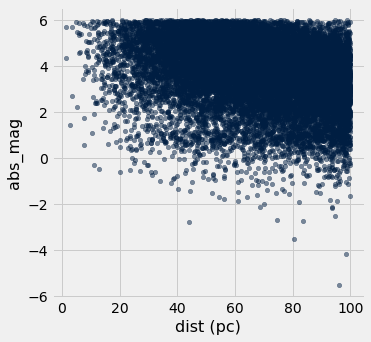

In [30]:
hip_100pc.where(5, are.below_or_equal_to(6)).scatter(6,5, alpha=0.5)

In [33]:
hip_100pc.where(5, are.below_or_equal_to(6))

HIP,RAdeg,DEdeg,Vmag,Plx,abs_mag,dist (pc),x,y,z
71681,219.914,-60.8395,1.35,742.12,5.70237,1.34749,-0.503598,-0.421285,-1.17671
71683,219.92,-60.8351,-0.01,742.12,4.34237,1.34749,-0.50362,-0.421397,-1.17666
32349,101.289,-16.7131,-1.44,379.21,1.4544,2.63706,-0.494399,2.4768,-0.758367
37279,114.827,5.22751,0.4,285.93,2.6813,3.49736,-1.46238,3.16092,0.318647
8102,26.0214,-15.9396,3.49,274.17,5.6801,3.64737,3.15162,1.5386,-1.00165
19849,63.8235,-7.64456,4.43,198.24,5.91596,5.04439,2.20549,4.4868,-0.671041
88601,271.363,2.50244,4.03,196.62,5.49814,5.08595,0.120896,-5.07966,0.222062
97649,297.695,8.86738,0.76,194.44,2.20393,5.14297,2.36167,-4.49936,0.792779
96100,293.086,69.6654,4.67,173.41,5.86537,5.76668,0.78576,-1.84346,5.4073
3821,12.2713,57.8165,3.46,167.99,4.58642,5.95274,3.09818,0.673883,5.03808
